**Análisis de Datos**

*   Cargar los datos
*   Hacer un análisis descriptivo
*   Gráficos


In [4]:
import pandas as pd

datos = pd.read_excel("/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_empresa.xlsx")
datos.head(3)

,ID Venta,Fecha,Departamento,Ciudad,Producto,Categoría,Canal,Vendedor,Cantidad (ton),Precio Unitario (COP/ton),Costo Unitario (COP/ton),Satisfacción (1-5),Latitud,Longitud,Ventas Totales (COP),Costo Total (COP),Utilidad (COP),Margen (%),Mes,Trimestre
0,VTA-0018,2024-01-01,Vichada,Puerto Carreño,Leche,Pecuario,Exportación,Camila Rojas,25.0,1871000,1446879,3,6.189,-67.486,46775000,3.617198e+07,10603025.0,0.226681,2024-01,T1-2024
1,VTA-0030,2024-01-03,Vichada,Puerto Carreño,Café,Cultivos perm.,Exportación,Laura Méndez,171.7,14921000,11052151,5,6.189,-67.486,2561935700,1.897654e+09,664281373.3,0.259289,2024-01,T1-2024
2,VTA-0157,2024-01-07,Antioquia,Medellín,Soya,Oleaginosas,Minorista,Diana Pérez,193.4,2635000,1610545,1,6.244,-75.581,509609000,3.114794e+08,198129597.0,0.388787,2024-01,T1-2024


In [10]:
import plotly.express as px
import pandas as pd
import sys
import plotly.io as pio

# Asegurarse de que la columna 'Mes' sea de tipo datetime
datos['Mes'] = pd.to_datetime(datos['Mes'])

# Crear el gráfico de dispersión con línea de tendencia
fig = px.scatter(datos,
                 x='Mes',
                 y='Ventas Totales (COP)',
                 title='Ventas Totales por Mes con Línea de Tendencia (Estático)',
                 labels={'Mes': 'Mes', 'Ventas Totales (COP)': 'Ventas Totales (COP)'},
                 trendline='ols',
                 trendline_color_override="red") # Añadir línea de tendencia OLS y darle un color

# Mejorar el diseño para un informe técnico
fig.update_layout(
    title_x=0.5, # Centrar el título
    font=dict(family="Arial, sans-serif", size=12, color="#333"),
    hovermode="x unified", # Mostrar información detallada al pasar el ratón
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    plot_bgcolor='white', # Fondo blanco para el plot
    paper_bgcolor='white' # Fondo blanco para el área del papel
)

# Añadir gridlines sutiles
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray', linecolor='black')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray', linecolor='black')

# Guardar el gráfico como una imagen estática (por ejemplo, PNG) con alta resolución
image_path = "ventas_por_mes_dispersión_informe.png"

try:
    fig.write_image(image_path, scale=2) # scale=2 para mayor resolución
    print(f"Gráfico estático para informe guardado como '{image_path}'")
except ValueError as e:
    print(f"Advertencia: No se pudo guardar el gráfico como imagen. Error: {e}")
    print("Aunque kaleido parece instalado, a veces es necesario reiniciar el entorno de ejecución de Colab (Runtime > Restart runtime...) para que plotly lo detecte correctamente.")
    print("El gráfico se mostrará a continuación de todos modos.")

# Mostrar el gráfico
fig.show()

Advertencia: No se pudo guardar el gráfico como imagen. Error: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Aunque kaleido parece instalado, a veces es necesario reiniciar el entorno de ejecución de Colab (Runtime > Restart runtime...) para que plotly lo detecte correctamente.
El gráfico se mostrará a continuación de todos modos.


In [11]:
import plotly.express as px

# Crear el gráfico de boxplot
fig = px.box(datos,
             x='Producto',
             y='Ventas Totales (COP)',
             title='Distribución de Ventas Totales por Producto',
             labels={'Producto': 'Producto', 'Ventas Totales (COP)': 'Ventas Totales (COP)'})

# Mejorar el diseño del gráfico
fig.update_layout(
    title_x=0.5, # Centrar el título
    font=dict(family="Arial, sans-serif", size=12, color="#333"),
    hovermode="closest",
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    plot_bgcolor='white', # Fondo blanco para el plot
    paper_bgcolor='white' # Fondo blanco para el área del papel
)

# Añadir gridlines sutiles
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray', linecolor='black')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray', linecolor='black')

fig.show()

In [14]:
import pandas as pd
import os

# Generar la tabla con métricas descriptivas para las variables numéricas
descripcion_numericas = datos.describe()

print("Métricas Descriptivas de las Variables Numéricas:")
print(descripcion_numericas)

# Definir la ruta base y el nombre de la nueva carpeta
base_path = "/content/drive/MyDrive/CURSO-INVESTIGACION-IA"
new_folder_name = "resumen"

# Construir la ruta completa de la carpeta de destino
output_directory = os.path.join(base_path, new_folder_name)

# Crear la carpeta si no existe
os.makedirs(output_directory, exist_ok=True)

# Definir el nombre del archivo Excel y la ruta completa
excel_file_name = "resumen.xlsx"
full_excel_path = os.path.join(output_directory, excel_file_name)

# Exportar las métricas a un archivo de Excel en la ruta especificada
descripcion_numericas.to_excel(full_excel_path)
print(f"Las métricas descriptivas se han exportado a '{full_excel_path}'.")

Métricas Descriptivas de las Variables Numéricas:
                               Fecha  Cantidad (ton)  \
count                            220      220.000000   
mean   2024-10-01 22:34:54.545454592      130.440455   
min              2024-01-01 00:00:00        9.200000   
25%              2024-05-26 00:00:00       63.425000   
50%              2024-09-24 12:00:00      117.500000   
75%              2025-02-14 12:00:00      179.625000   
max              2025-06-27 00:00:00      371.100000   
std                              NaN       85.526266   

       Precio Unitario (COP/ton)  Costo Unitario (COP/ton)  \
count               2.200000e+02              2.200000e+02   
mean                5.138027e+06              3.570058e+06   
min                 1.286000e+06              7.674890e+05   
25%                 1.673000e+06              1.176050e+06   
50%                 2.851500e+06              1.890062e+06   
75%                 1.005575e+07              6.770902e+06   
max        


--- Métricas de Desempeño del Modelo de Regresión Lineal ---
                                OLS Regression Results                               
Dep. Variable:     Q("Ventas Totales (COP)")   R-squared:                       0.697
Model:                                   OLS   Adj. R-squared:                  0.696
Method:                        Least Squares   F-statistic:                     501.7
Date:                       Tue, 23 Jun 2026   Prob (F-statistic):           1.87e-58
Time:                               16:29:25   Log-Likelihood:                -4787.3
No. Observations:                        220   AIC:                             9579.
Df Residuals:                            218   BIC:                             9585.
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                                    coef    std err          t      P>|t|     

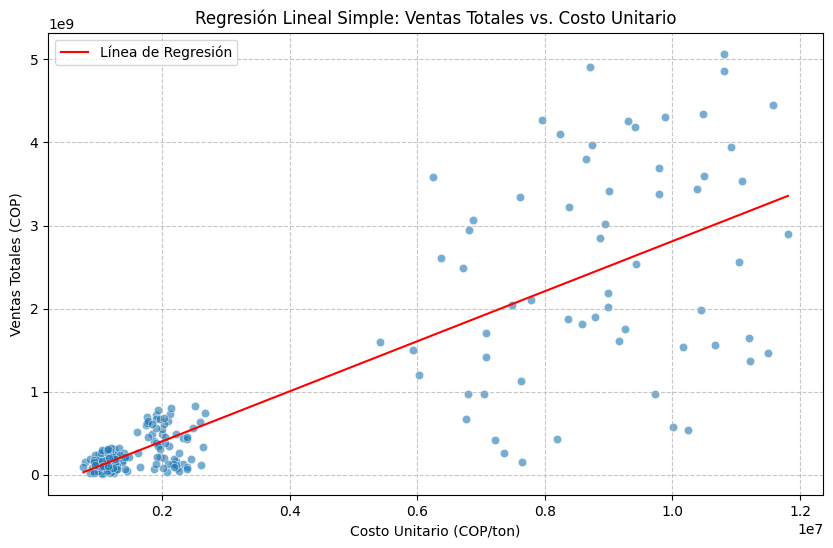

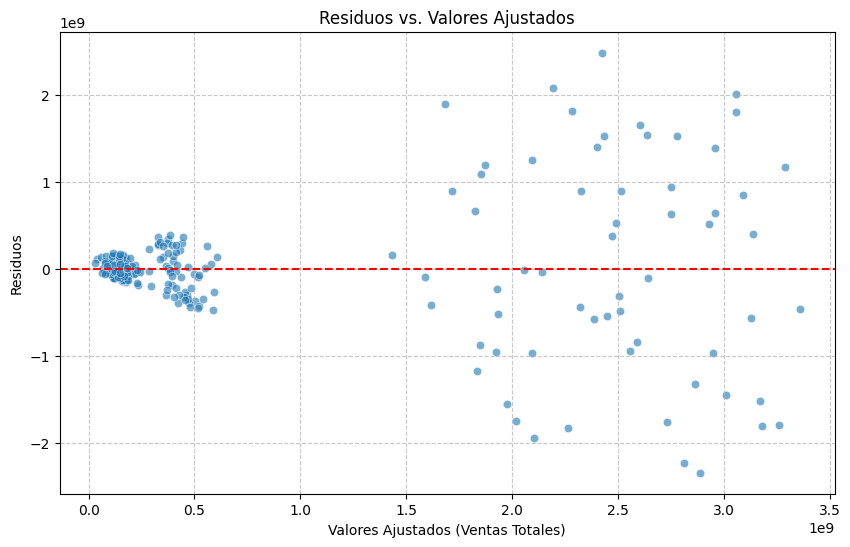

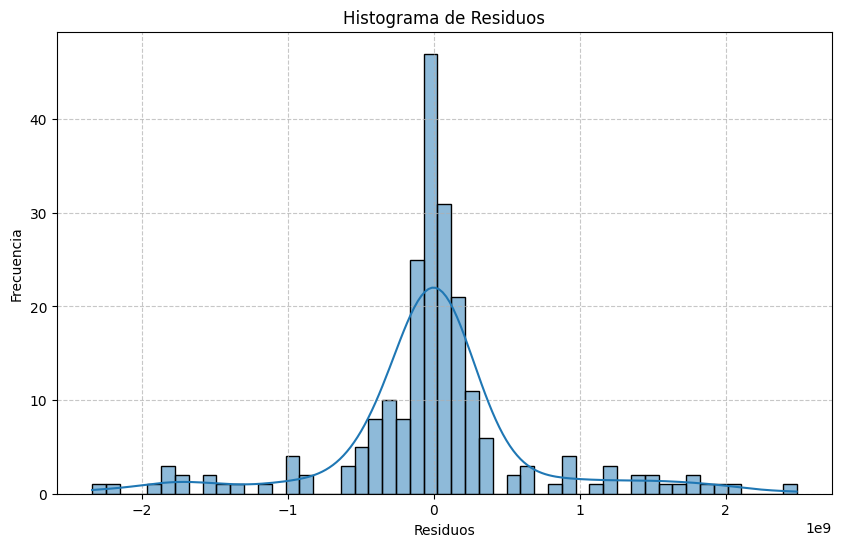

<Figure size 1000x600 with 0 Axes>

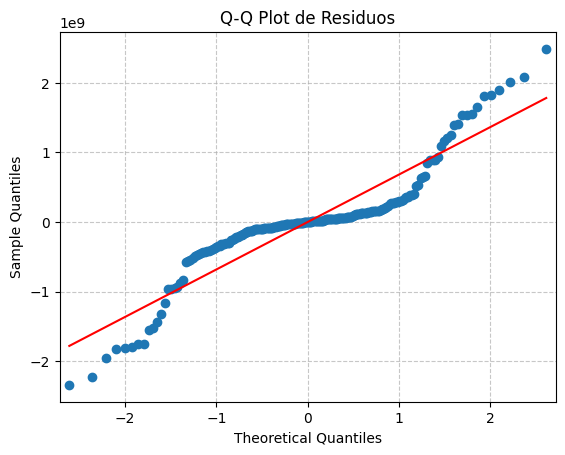

In [15]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir las variables
x = datos['Costo Unitario (COP/ton)']
y = datos['Ventas Totales (COP)']

# Crear el modelo de regresión lineal simple
# La fórmula es 'variable_dependiente ~ variable_independiente'
model = smf.ols('Q("Ventas Totales (COP)") ~ Q("Costo Unitario (COP/ton)")', data=datos).fit()

print("\n--- Métricas de Desempeño del Modelo de Regresión Lineal ---")
print(model.summary())

print("\n--- Visualización del Modelo de Regresión Lineal ---")

# Gráfico de dispersión con la línea de regresión
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, data=datos, alpha=0.6)
sns.lineplot(x=x, y=model.predict(datos), color='red', label='Línea de Regresión')
plt.title('Regresión Lineal Simple: Ventas Totales vs. Costo Unitario')
plt.xlabel('Costo Unitario (COP/ton)')
plt.ylabel('Ventas Totales (COP)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Gráfico de residuos vs. valores ajustados
plt.figure(figsize=(10, 6))
sns.scatterplot(x=model.predict(datos), y=model.resid, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs. Valores Ajustados')
plt.xlabel('Valores Ajustados (Ventas Totales)')
plt.ylabel('Residuos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Histograma de residuos
plt.figure(figsize=(10, 6))
sns.histplot(model.resid, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Q-Q plot de residuos para verificar normalidad
import statsmodels.api as sm
plt.figure(figsize=(10, 6))
sm.qqplot(model.resid, line='s')
plt.title('Q-Q Plot de Residuos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [17]:
import os
import pandas as pd

# Obtener la ruta del directorio de trabajo actual (donde se está ejecutando el notebook)
# O, si se prefiere una ruta específica en Drive, se puede modificar como:
base_path = "/content/drive/MyDrive/CURSO-INVESTIGACION-IA"
# Para este caso, usaremos el directorio actual para guardar la nueva carpeta
# base_path = os.getcwd()

# Definir el nombre de la nueva carpeta
folder_name = "ventas_departamentos"
output_folder_path = os.path.join(base_path, folder_name)

# Crear la carpeta si no existe
os.makedirs(output_folder_path, exist_ok=True)
print(f"Carpeta '{output_folder_path}' creada o ya existente.")

# Obtener la lista de departamentos únicos
departamentos_unicos = datos['Departamento'].unique()

# Iterar sobre cada departamento y guardar su información en un archivo Excel
for departamento in departamentos_unicos:
    # Filtrar el DataFrame para el departamento actual
    df_departamento = datos[datos['Departamento'] == departamento]

    # Limpiar el nombre del departamento para usarlo en el nombre del archivo (quitar espacios, caracteres especiales, etc.)
    # Esto es importante para evitar errores al crear archivos con nombres inválidos
    nombre_archivo_limpio = departamento.replace(' ', '_').replace('/', '_').replace('\\', '_') # Ejemplo simple de limpieza

    # Definir el nombre del archivo Excel
    excel_file_name = f"ventas_{nombre_archivo_limpio}.xlsx"

    # Construir la ruta completa del archivo
    file_path = os.path.join(output_folder_path, excel_file_name)

    # Guardar el DataFrame filtrado en un archivo Excel
    df_departamento.to_excel(file_path, index=False) # index=False para no guardar el índice del DataFrame
    print(f"Archivo '{excel_file_name}' guardado en '{output_folder_path}'")

print("Proceso completado: Archivos Excel de ventas por departamento generados.")

Carpeta '/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_departamentos' creada o ya existente.
Archivo 'ventas_Vichada.xlsx' guardado en '/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_departamentos'
Archivo 'ventas_Antioquia.xlsx' guardado en '/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_departamentos'
Archivo 'ventas_Tolima.xlsx' guardado en '/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_departamentos'
Archivo 'ventas_Casanare.xlsx' guardado en '/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_departamentos'
Archivo 'ventas_Cundinamarca.xlsx' guardado en '/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_departamentos'
Archivo 'ventas_Meta.xlsx' guardado en '/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_departamentos'
Archivo 'ventas_Arauca.xlsx' guardado en '/content/drive/MyDrive/CURSO-INVESTIGACION-IA/ventas_departamentos'
Proceso completado: Archivos Excel de ventas por departamento generados.
